<a href="https://colab.research.google.com/github/deorakamlesh07-droid/Celabal_CEI/blob/main/week6_kamleshdeora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Week 6 Autoencoder for Image Denoising using MNIST Dataset
## Problem Statement

Develop a Denoising Autoencoder using the MNIST dataset to reconstruct clean handwritten digit images from noisy inputs. The project aims to learn meaningful image representations through an encoder–decoder architecture while effectively removing noise and preserving the original digit structure. The model is evaluated by comparing the original, noisy, and reconstructed images.


## 1. Project Introduction

* Developed a **Convolutional Denoising Autoencoder** to reconstruct clean handwritten digit images from noisy MNIST images.
* Preprocessed the MNIST dataset by **normalizing pixel values** and generating **Gaussian noise** to create noisy input images.
* Designed an **Encoder–Decoder architecture** using Conv2D, MaxPooling2D, Batch Normalization, and UpSampling2D layers for effective feature extraction and image reconstruction.
* Trained the model using the **Adam optimizer** and **Mean Squared Error (MSE)** loss, with **Early Stopping** and **ReduceLROnPlateau** callbacks to improve training stability.
* Evaluated the model through **visual comparison of original, noisy, and reconstructed images** and analyzed its denoising performance using image quality metrics such as **PSNR**.



##  Implementation Plan

The implementation of this project follows a systematic workflow to build and evaluate a denoising autoencoder using the MNIST dataset.

1. **Load the MNIST Dataset:** Import the handwritten digit dataset and split it into training and testing sets.

2. **Preprocess the Data:** Normalize pixel values to the range of 0–1 and reshape the images into the required format for convolutional neural networks.

3. **Generate Noisy Images:** Add Gaussian noise to the original images to create noisy inputs while keeping the clean images as target outputs.

4. **Visualize the Dataset:** Display original and noisy images to verify the preprocessing and noise generation process.

5. **Build the Denoising Autoencoder:** Design a convolutional encoder-decoder architecture using Conv2D, MaxPooling2D, Batch Normalization, and UpSampling2D layers to learn compressed image representations and reconstruct clean images.

6. **Compile and Train the Model:** Compile the model using the Adam optimizer and Mean Squared Error (MSE) loss function. Train the autoencoder with noisy images as input and clean images as target, using Early Stopping and ReduceLROnPlateau callbacks for stable training.

7. **Evaluate Model Performance:** Monitor training and validation loss to assess learning and identify convergence during training.

8. **Generate Denoised Images:** Use the trained model to reconstruct clean images from noisy test images and compare the outputs with the original images.

9. **Analyze the Results:** Evaluate the denoising performance through visual comparison and image quality metrics such as PSNR, followed by observations, challenges, and conclusions.


## 2. Import Required Libraries

Only the libraries required for loading data, building the model, numerical processing, and visualization are imported.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 3. Load Dataset

The MNIST dataset contains grayscale handwritten digit images from 0 to 9. It is suitable for image denoising because the images are small, clean, structured, and widely used for beginner-friendly deep learning experiments.


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)
print("Number of classes:", len(np.unique(y_train)))
print("Classes in the MNIST dataset:")
print(np.unique(y_train))


Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)
Training labels shape: (60000,)
Testing labels shape: (10000,)
Number of classes: 10
Classes in the MNIST dataset:
[0 1 2 3 4 5 6 7 8 9]


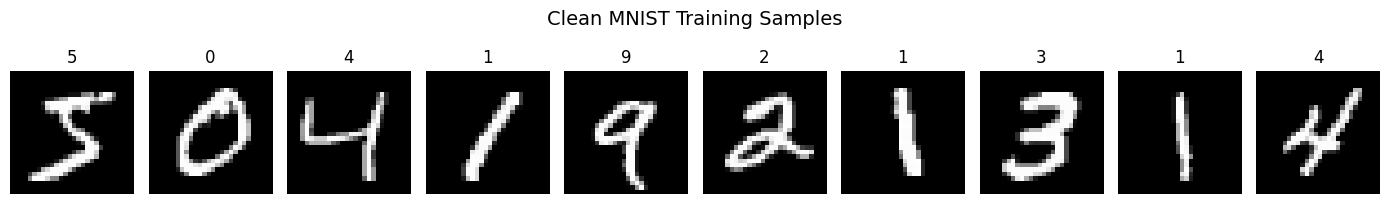

In [ ]:
def show_digit_grid(images, labels=None, count=10, title="Sample Images"):
    """Display a row of MNIST digit images."""
    plt.figure(figsize=(14, 2.2))
    for i in range(count):
        plt.subplot(1, count, i + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.axis("off")
        if labels is not None:
            plt.title(str(labels[i]))
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_digit_grid(x_train, y_train, count=10, title="Clean MNIST Training Samples")


## 4. Data Preprocessing

Neural networks train more reliably when input values are on a small, consistent scale. MNIST pixels originally range from 0 to 255, so they are normalized to the range 0 to 1. The images are also reshaped from `(28, 28)` to `(28, 28, 1)` because convolutional layers expect a channel dimension.


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Preprocessed training shape:", x_train.shape)
print("Preprocessed testing shape:", x_test.shape)
print("Pixel range after normalization:", x_train.min(), "to", x_train.max())


Preprocessed training shape: (60000, 28, 28, 1)
Preprocessed testing shape: (10000, 28, 28, 1)
Pixel range after normalization: 0.0 to 1.0


## 5. Noise Generation

Gaussian noise is added to create noisy input images. The clean image remains the target output. Clipping is required because adding noise can push pixel values below 0 or above 1, while valid normalized image pixels must stay inside the range `[0, 1]`.


In [ ]:
def add_gaussian_noise(images, noise_factor=0.3):
    """Add Gaussian noise and clip pixel values to the valid [0, 1] range."""
    noise = noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy_images = images + noise
    return np.clip(noisy_images, 0.0, 1.0).astype("float32")

# A moderate value keeps digit structure visible while still creating a real denoising task.
NOISE_FACTOR = 0.45
x_train_noisy = add_gaussian_noise(x_train, noise_factor=NOISE_FACTOR)
x_test_noisy = add_gaussian_noise(x_test, noise_factor=NOISE_FACTOR)

print("Clean training range:", x_train.min(), "to", x_train.max())
print("Noisy training range:", x_train_noisy.min(), "to", x_train_noisy.max())
print("Noisy training mean:", x_train_noisy.mean())


Clean training range: 0.0 to 1.0
Noisy training range: 0.0 to 1.0
Noisy training mean: 0.2618327


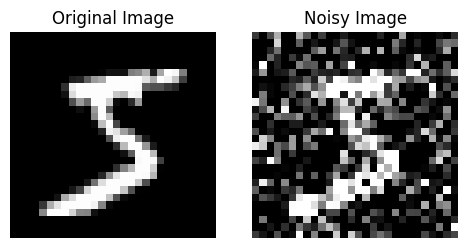

In [ ]:
def compare_clean_noisy(clean_images, noisy_images, index=0):
    plt.figure(figsize=(5, 2.5))

    plt.subplot(1, 2, 1)
    plt.imshow(clean_images[index].squeeze(), cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(noisy_images[index].squeeze(), cmap="gray")
    plt.title("Noisy Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

compare_clean_noisy(x_train, x_train_noisy, index=0)


## 6. Visualize Noisy Images

The following visualization compares clean MNIST images with their noisy versions. The noisy dataset is used as the model input, while the original clean dataset is used as the reconstruction target.


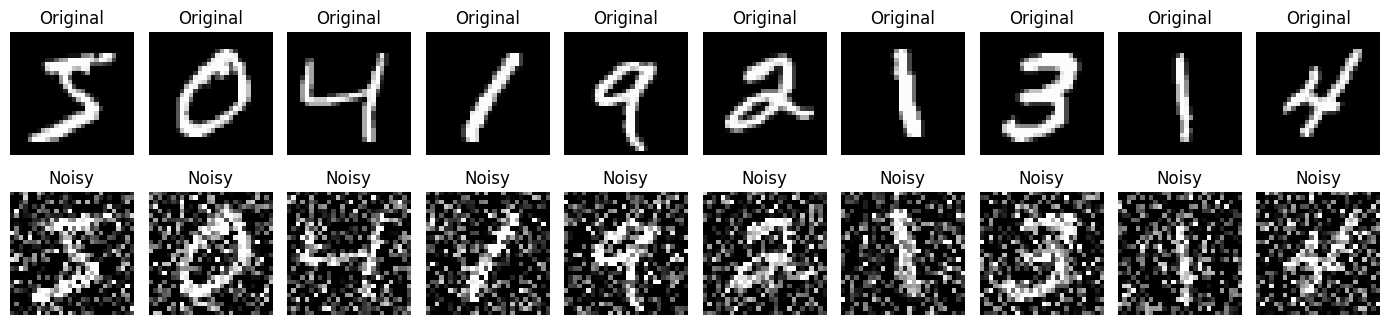

In [ ]:
def show_original_vs_noisy(clean_images, noisy_images, count=10):
    plt.figure(figsize=(14, 3.5))
    for i in range(count):
        plt.subplot(2, count, i + 1)
        plt.imshow(clean_images[i].squeeze(), cmap="gray")
        plt.title("Original")
        plt.axis("off")

        plt.subplot(2, count, i + 1 + count)
        plt.imshow(noisy_images[i].squeeze(), cmap="gray")
        plt.title("Noisy")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_original_vs_noisy(x_train, x_train_noisy, count=10)


## 7. Build Denoising Autoencoder

This model is a convolutional autoencoder.

- **Encoder:** uses `Conv2D` layers with ReLU activation to learn local image features, followed by `MaxPooling2D` to reduce spatial size.
- **Bottleneck:** stores a compressed latent representation of the digit.
- **Decoder:** uses `Conv2D` and `UpSampling2D` layers to reconstruct the image resolution.
- **Sigmoid output:** keeps reconstructed pixel values between 0 and 1, matching the normalized image range.

The architecture is intentionally compact and symmetric enough for MNIST denoising without becoming unnecessarily deep. Batch normalization is added after hidden convolutions to make training more stable and avoid collapsed black reconstructions.


In [ ]:
def build_denoising_autoencoder(input_shape=(28, 28, 1)):
    """Create a stable convolutional denoising autoencoder for MNIST."""
    inputs = layers.Input(shape=input_shape, name="noisy_input")

    # Encoder: extract digit strokes and reduce spatial size.
    x = layers.Conv2D(32, (3, 3), padding="same", kernel_initializer="he_normal", name="encoder_conv_1")(inputs)
    x = layers.BatchNormalization(name="encoder_bn_1")(x)
    x = layers.Activation("relu", name="encoder_relu_1")(x)
    x = layers.MaxPooling2D((2, 2), padding="same", name="encoder_pool_1")(x)

    x = layers.Conv2D(64, (3, 3), padding="same", kernel_initializer="he_normal", name="encoder_conv_2")(x)
    x = layers.BatchNormalization(name="encoder_bn_2")(x)
    x = layers.Activation("relu", name="encoder_relu_2")(x)
    encoded = layers.MaxPooling2D((2, 2), padding="same", name="bottleneck")(x)

    # Decoder: rebuild the 28x28 clean digit image.
    x = layers.Conv2D(64, (3, 3), padding="same", kernel_initializer="he_normal", name="decoder_conv_1")(encoded)
    x = layers.BatchNormalization(name="decoder_bn_1")(x)
    x = layers.Activation("relu", name="decoder_relu_1")(x)
    x = layers.UpSampling2D((2, 2), name="decoder_upsample_1")(x)

    x = layers.Conv2D(32, (3, 3), padding="same", kernel_initializer="he_normal", name="decoder_conv_2")(x)
    x = layers.BatchNormalization(name="decoder_bn_2")(x)
    x = layers.Activation("relu", name="decoder_relu_2")(x)
    x = layers.UpSampling2D((2, 2), name="decoder_upsample_2")(x)

    outputs = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="reconstructed_output")(x)
    return models.Model(inputs, outputs, name="mnist_denoising_autoencoder")

autoencoder = build_denoising_autoencoder()
autoencoder.summary()


Model: "mnist_denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_1                    │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_relu_1 (Activation)     │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool_1 (MaxPooling2D)   │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_2                    │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_relu_2 (Activation)     │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (MaxPooling2D)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_1 (Conv2D)         │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_1                    │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_relu_1 (Activation)     │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsample_1              │ (None, 14, 14, 64)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_2 (Conv2D)         │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_2                    │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_relu_2 (Activation)     │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsample_2              │ (None, 28, 28, 32)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_output (Conv2D)   │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,265 (294.00 KB)

 Trainable params: 74,881 (292.50 KB)

 Non-trainable params: 384 (1.50 KB)

## 8. Model Compilation

The model is compiled with the Adam optimizer and Mean Squared Error loss.

MSE is suitable for image reconstruction because it directly measures pixel-wise difference between the clean image and reconstructed image. Cross entropy is more common for classification or probabilistic binary outputs, while MSE is intuitive for regression-style reconstruction tasks.


In [ ]:
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)


## 9. Model Training

The model receives noisy images as input and clean images as targets.

This teaches the network to map corrupted images back to their original clean structure. A validation split is used to monitor generalization during training. Early stopping and learning-rate reduction are included as practical enhancements to avoid unnecessary training and help the optimizer continue improving if validation loss plateaus.


In [ ]:
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_split=0.1,
    callbacks=[early_stopping, reduce_lr]
)


Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - loss: 0.0176 - val_loss: 0.0130 - learning_rate: 0.0010
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - loss: 0.0105 - val_loss: 0.0104 - learning_rate: 0.0010
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - loss: 0.0098 - val_loss: 0.0098 - learning_rate: 0.0010
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - loss: 0.0094 - val_loss: 0.0095 - learning_rate: 0.0010
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - loss: 0.0092 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - loss: 0.0090 - val_loss: 0.0091 - learning_rate: 0.0010
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - loss: 0.0088 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - loss: 0.0087 - val_loss: 0.0089 - learning_rate: 0.0010
Epoch 9/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - loss: 0.0086 - val_loss: 0.0088 - learning_rate:

## 10. Training Visualization

The loss curves help evaluate convergence. If both training and validation loss decrease and remain close, the model is learning well. A large gap may indicate overfitting, while high losses for both curves may indicate underfitting.


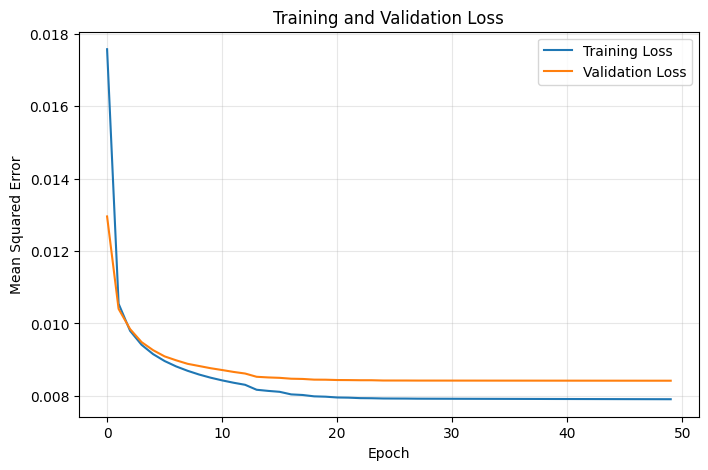

In [ ]:
def plot_training_history(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Mean Squared Error")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_training_history(history)


## 11. Image Reconstruction

The trained autoencoder is used to denoise noisy test images. Each sample below shows the original image, noisy input, and reconstructed output.


In [ ]:
denoised_test_images = autoencoder.predict(x_test_noisy)

print("Prediction range:", denoised_test_images.min(), "to", denoised_test_images.max())
print("Prediction mean:", denoised_test_images.mean())
print("Test MSE after denoising:", autoencoder.evaluate(x_test_noisy, x_test, verbose=0))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Prediction range: 9.437212e-09 to 0.9983487
Prediction mean: 0.13223962
Test MSE after denoising: 0.008206948637962341


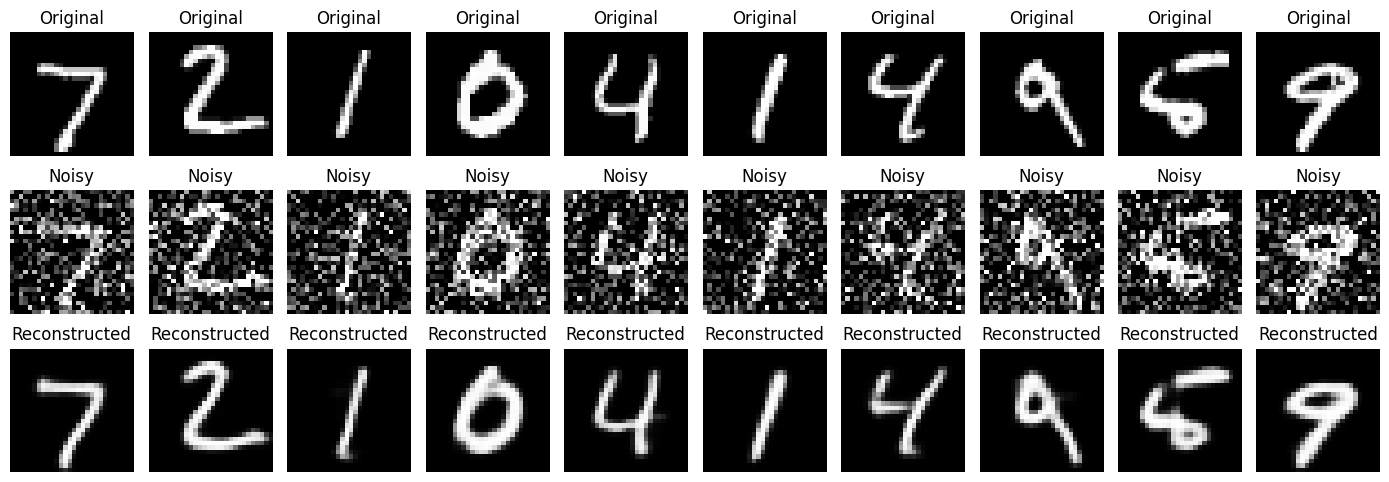

In [ ]:
def show_reconstruction_results(clean_images, noisy_images, reconstructed_images, count=10):
    plt.figure(figsize=(14, 5))
    for i in range(count):
        plt.subplot(3, count, i + 1)
        plt.imshow(clean_images[i].squeeze(), cmap="gray")
        plt.title("Original")
        plt.axis("off")

        plt.subplot(3, count, i + 1 + count)
        plt.imshow(noisy_images[i].squeeze(), cmap="gray")
        plt.title("Noisy")
        plt.axis("off")

        plt.subplot(3, count, i + 1 + 2 * count)
        plt.imshow(reconstructed_images[i].squeeze(), cmap="gray")
        plt.title("Reconstructed")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_reconstruction_results(x_test, x_test_noisy, denoised_test_images, count=10)


## 12. Performance Analysis

The reconstructed images should contain much less random background noise than the noisy inputs. A good denoising autoencoder preserves the overall digit shape while smoothing corrupted pixels.

Expected observations:

- Most digit strokes become clearer after reconstruction.
- Background noise is reduced significantly.
- Some outputs may look slightly blurry because the model optimizes average pixel reconstruction error.
- Very noisy or thin digit strokes may be reconstructed imperfectly.
- The bottleneck helps remove noise by forcing the model to keep only important digit structure.
- Convolutional layers are effective because they learn local spatial patterns such as edges, curves, and strokes.


## Optional Innovation: Quantitative PSNR Metric

Peak Signal-to-Noise Ratio (PSNR) is a common image quality metric. Higher PSNR usually indicates that the reconstructed image is closer to the clean original.


In [ ]:
def calculate_average_psnr(clean_images, compared_images):
    psnr_values = tf.image.psnr(clean_images, compared_images, max_val=1.0)
    return float(tf.reduce_mean(psnr_values).numpy())

noisy_psnr = calculate_average_psnr(x_test, x_test_noisy)
denoised_psnr = calculate_average_psnr(x_test, denoised_test_images)

print(f"Average PSNR of noisy test images: {noisy_psnr:.2f} dB")
print(f"Average PSNR after denoising: {denoised_psnr:.2f} dB")


Average PSNR of noisy test images: 10.12 dB
Average PSNR after denoising: 21.20 dB


## 13. Challenges Faced

Several practical choices affect denoising quality:

- Choosing the noise level is important. Too little noise makes the task easy, while too much noise can hide digit structure.
- MSE can produce slightly blurry images because it rewards average pixel correctness.
- Too few epochs may underfit, while too many epochs may overfit the training data.
- Validation loss and visual inspection are both needed because low loss does not always guarantee visually perfect reconstructions.


## 14. Key Learnings

* Understood the working of **Denoising Autoencoders** and how they reconstruct clean images from noisy inputs.
* Learned to **preprocess image data**, including normalization and Gaussian noise generation.
* Gained hands-on experience in designing an **Encoder–Decoder architecture** using Convolutional Neural Networks (CNNs).
* Learned how to train deep learning models using the **Adam optimizer**, **MSE loss**, and callbacks such as **Early Stopping** and **ReduceLROnPlateau**.
* Explored model evaluation through **visual reconstruction** and image quality metrics like **PSNR**.

## Why This Project is Useful

* Builds a strong foundation in **image reconstruction** and **deep learning** concepts.
* Demonstrates the practical use of **autoencoders** for noise removal and feature learning.
* Introduces real-world applications in **medical imaging, document restoration, satellite imaging, and OCR preprocessing**.
* Enhances understanding of **CNN-based encoder–decoder architectures**, which are widely used in modern computer vision tasks.
* Provides practical experience with the complete deep learning workflow, from data preparation to model evaluation and performance analysis.

##  Conclusion

This project implemented a convolutional denoising autoencoder for the MNIST dataset. The workflow included loading MNIST, normalizing pixel values, reshaping images for CNN layers, generating Gaussian noise, training an encoder-decoder model, and reconstructing clean digit images from noisy inputs.

The encoder compressed each noisy image into a latent bottleneck representation, while the decoder reconstructed the denoised image. Adam optimizer and MSE loss provided a simple and effective training setup for pixel-level reconstruction. Visual comparisons and PSNR measurement show whether the model successfully reduces noise while preserving the handwritten digit structure.

Overall, this notebook demonstrates how denoising autoencoders can learn meaningful image representations and use them to restore corrupted visual data.


## Future Improvements

* Experiment with different **noise levels** to evaluate the model's denoising capability.
* Build a **deeper autoencoder architecture** to improve reconstruction quality.
* Use **SSIM (Structural Similarity Index)** along with PSNR for better image quality evaluation.
* Compare **Mean Squared Error (MSE)** with **Binary Crossentropy** as the loss function.
* Test the model on **custom handwritten digit images** to evaluate its generalization performance.
